# Academic Summary: RoFormer — Enhanced Transformer with Rotary Position Embedding

# https://arxiv.org/pdf/2104.09864

---

## Abstract

RoFormer introduces Rotary Position Embedding (RoPE), a novel positional encoding scheme for
transformer-based language models. RoPE encodes absolute token positions via a rotation matrix
while naturally incorporating relative position dependencies into the self-attention formulation.
The method offers sequence length flexibility, long-term decay of inter-token dependency, and
compatibility with linear self-attention. Evaluated on machine translation, pre-training, and
downstream NLP benchmarks, RoFormer consistently matches or outperforms strong baselines.

---

## Problems

- Standard transformer self-attention is position-agnostic; positional information must be
  injected externally.
- Existing absolute position embeddings (sinusoidal or trainable) add position to token
  representations before projection, losing relative position signal in attention.
- Existing relative position encoding methods decompose the attention score additively
  (e.g., Transformer-XL, DeBERTa), leading to complex formulations and incompatibility
  with linear self-attention architectures.
- No prior method simultaneously provides: (1) relative position encoding, (2) sequence
  length flexibility, (3) long-term decay, and (4) linear attention compatibility.

---

## Proposed Solution

**Rotary Position Embedding (RoPE):** A multiplicative positional encoding that rotates query
and key vectors by an angle proportional to their absolute position before the inner product,
such that the resulting attention score depends only on the relative position $m - n$.

The core design goal is to find functions $f_q$, $f_k$ such that:

$$\langle f_q(x_m, m),\ f_k(x_n, n) \rangle = g(x_m, x_n, m - n)$$

---

## Purpose

- Provide a theoretically grounded, geometrically interpretable positional encoding for
  transformers.
- Unify absolute and relative position encoding within a single multiplicative framework.
- Enable compatibility with efficient linear attention mechanisms while preserving relative
  position sensitivity.

---

## Methodology

### Derivation (2D Case)

In 2D, the solution is expressed using complex number rotation:

$$f_q(x_m, m) = (W_q x_m)\, e^{im\theta}, \quad f_k(x_n, n) = (W_k x_n)\, e^{in\theta}$$

The inner product then yields:

$$q_m^\top k_n = \mathrm{Re}\left[(W_q x_m)(W_k x_n)^* e^{i(m-n)\theta}\right]$$

which depends only on $m - n$, satisfying the relative position constraint.

### General Form ($d$-dimensional)

The $d$-dimensional embedding space is divided into $d/2$ 2D sub-spaces. The rotary matrix is:

$$R^d_{\Theta, m} = \begin{pmatrix}
\cos m\theta_1 & -\sin m\theta_1 & 0 & \cdots \\
\sin m\theta_1 & \cos m\theta_1 & 0 & \cdots \\
0 & 0 & \cos m\theta_2 & \cdots \\
\vdots & & & \ddots
\end{pmatrix}$$

with pre-defined frequencies $\Theta = \{\theta_i = 10000^{-2(i-1)/d},\ i \in [1, \ldots, d/2]\}$.

The RoPE-augmented self-attention score becomes:

$$q_m^\top k_n = x_m^\top W_q\, R^d_{\Theta, n-m}\, W_k x_n$$

### Efficient Computation

Exploiting the sparsity of $R^d_{\Theta,m}$, matrix multiplication is replaced by element-wise
operations:

$$R^d_{\Theta,m} x = x \otimes \cos(m\Theta) + \tilde{x} \otimes \sin(m\Theta)$$

where $\tilde{x}$ interleaves negated pairs of $x$.

### Linear Attention Compatibility

RoPE is integrated into linear attention (Performer) by applying the rotation matrix after the
feature map functions $\phi(\cdot)$, $\varphi(\cdot)$, preserving the $O(N)$ complexity.

### Key Properties

| Property | Description |
|---|---|
| Relative position encoding | Attention score depends only on $m - n$ |
| Long-term decay | Inner product magnitude decreases as $\|m - n\|$ increases |
| Sequence length flexibility | No fixed maximum length; generalizes beyond training length |
| Linear attention compatible | Rotation applied post-feature-map without breaking linearity |

### Experimental Setup

| Task | Dataset | Baseline | Metric |
|---|---|---|---|
| Machine Translation | WMT 2014 En-De | Transformer-base | BLEU |
| Pre-training (English) | BookCorpus + Wikipedia | BERT-base-uncased | MLM Loss |
| Fine-tuning | GLUE (MRPC, SST-2, QNLI, STS-B, QQP, MNLI) | BERT | Accuracy / F1 / Spearman |
| Linear Attention | Enwik8 | Performer | LM Loss |
| Long-text Chinese | CAIL2019-SCM | BERT, WoBERT, NEZHA | Accuracy |

---

## Results

### Machine Translation (WMT 2014 En-De)

| Model | BLEU |
|---|---|
| Transformer-base | 27.3 |
| RoFormer | **27.5** |

### Pre-training Convergence

RoFormer reaches lower MLM loss faster than BERT across 250K training steps.
Performer with RoPE achieves lower LM loss than Performer without RoPE across 100K steps.

### GLUE Fine-tuning

| Model | MRPC | SST-2 | QNLI | STS-B | QQP | MNLI (m/mm) |
|---|---|---|---|---|---|---|
| BERT | 88.9 | **93.5** | **90.5** | 85.8 | 71.2 | **84.6/83.4** |
| RoFormer | **89.5** | 90.7 | 88.0 | **87.0** | **86.4** | 80.2/79.8 |

RoFormer outperforms BERT on 3 of 6 tasks with considerable margins on STS-B and QQP.

### Long-text Chinese (CAIL2019-SCM)

| Model | Validation | Test |
|---|---|---|
| BERT-512 | 64.13% | 67.77% |
| WoBERT-512 | 64.07% | 68.10% |
| RoFormer-512 | 64.13% | 68.29% |
| RoFormer-1024 | **66.07%** | **69.79%** |

Extending input length to 1024 tokens yields a +1.5% absolute improvement over WoBERT-512,
demonstrating RoPE's generalization to longer sequences.

---

## Conclusions

- RoPE offers a principled, geometrically motivated alternative to additive positional encoding
  by rotating query and key vectors in 2D sub-spaces, inherently encoding relative positions.
- The approach is multiplicative rather than additive, enabling clean integration with both
  standard and linear self-attention.
- Theoretical analysis confirms long-term decay behavior, aligning with the linguistic
  intuition that distant tokens should have weaker attention coupling.
- Empirical results demonstrate faster convergence during pre-training and competitive or
  superior downstream task performance compared to BERT and standard Transformer baselines.
- RoPE's sequence-length flexibility is practically validated by superior performance on
  long Chinese legal documents at 1024 tokens.
- Acknowledged limitations include the absence of a formal explanation for faster convergence
  and for the superior long-text performance beyond the proven decay property.
- RoPE has been widely adopted in subsequent large language models (e.g., LLaMA, PaLM 2),
  making this paper a foundational contribution to modern transformer position encoding.

# Mathematical & Statistical Content: RoFormer / RoPE

---

## 1. Self-Attention Formulation (Foundation)

### Attention Weight and Output

$$a_{m,n} = \frac{\exp\!\left(\dfrac{q_m^\top k_n}{\sqrt{d}}\right)}{\sum_{j=1}^{N} \exp\!\left(\dfrac{q_m^\top k_j}{\sqrt{d}}\right)}, \qquad o_m = \sum_{n=1}^{N} a_{m,n}\, v_n$$

**What it means:** Standard scaled dot-product attention. Query vector $q_m$ at position $m$
attends to all key vectors $k_n$. The dot product $q_m^\top k_n$ measures compatibility; the
softmax normalizes these into a probability distribution over values $v_n$. Dividing by
$\sqrt{d}$ prevents gradient vanishing for large dimensions.

**Role in paper:** Establishes the baseline attention mechanism that RoPE is designed to
augment with positional awareness.

---

## 2. Position Encoding Problem — Core Constraint

$$\langle f_q(x_m, m),\ f_k(x_n, n) \rangle = g(x_m,\, x_n,\, m - n)$$

**What it means:** The central mathematical requirement of RoPE. The inner product of the
position-encoded query and key must depend only on the token embeddings $x_m$, $x_n$ and
their **relative** position $m - n$, not their absolute positions independently. This is the
functional equation that the entire derivation solves.

**Role in paper:** The design target. All subsequent mathematics is dedicated to finding
$f_q$ and $f_k$ that satisfy this constraint.

---

## 3. Absolute Position Embedding (Prior Work Baseline)

$$f_{t \in \{q,k,v\}}(x_i, i) := W_t(x_i + p_i)$$

**Sinusoidal variant:**

$$p_{i,2t} = \sin\!\left(\frac{k}{10000^{2t/d}}\right), \qquad p_{i,2t+1} = \cos\!\left(\frac{k}{10000^{2t/d}}\right)$$

**What it means:** The original Transformer adds a fixed position vector $p_i$ directly to
the token embedding before linear projection. The sinusoidal version uses alternating sine
and cosine functions at geometrically spaced frequencies to generate these vectors.

**Role in paper:** The baseline that RoPE improves upon. Adding position before projection
mixes positional and semantic information and cannot naturally express relative positions.

---

## 4. Relative Position Embedding Variants (Prior Work Survey)

### Shaw et al. decomposition:
$$q_m^\top k_n = x_m^\top W_q^\top W_k x_n + x_m^\top W_q^\top W_k p_n + p_m^\top W_q^\top W_k x_n + p_m^\top W_q^\top W_k p_n$$

### Transformer-XL (Dai et al.) — replaces absolute $p_n$ with relative $\tilde{p}_{m-n}$:
$$q_m^\top k_n = x_m^\top W_q^\top W_k x_n + x_m^\top W_q^\top \tilde{W}_k \tilde{p}_{m-n} + u^\top W_q^\top W_k x_n + v^\top W_q^\top \tilde{W}_k \tilde{p}_{m-n}$$

### T5 (Raffel et al.) — scalar bias:
$$q_m^\top k_n = x_m^\top W_q^\top W_k x_n + b_{i,j}$$

### DeBERTa (He et al.) — middle two terms only:
$$q_m^\top k_n = x_m^\top W_q^\top W_k x_n + x_m^\top W_q^\top W_k \tilde{p}_{m-n} + \tilde{p}_{m-n}^\top W_q^\top W_k x_n$$

**What it means:** Each variant decomposes the attention score into content-content,
content-position, and position-position interaction terms, then substitutes relative offsets
$\tilde{p}_{m-n}$ for absolute position vectors. All remain additive modifications of the
same original decomposition.

**Role in paper:** Establishes that all prior relative encoding methods are additive and
share structural limitations, motivating the multiplicative RoPE approach.

---

## 5. RoPE Derivation — 2D Case

### Complex number representation of $f_q$, $f_k$, $g$:

$$f_q(x_q, m) = R_q(x_q, m)\, e^{i\Theta_q(x_q, m)}$$
$$f_k(x_k, n) = R_k(x_k, n)\, e^{i\Theta_k(x_k, n)}$$
$$g(x_q, x_k, n-m) = R_g(x_q, x_k, n-m)\, e^{i\Theta_g(x_q, x_k, n-m)}$$

**What it means:** Each function is decomposed into a radial (magnitude) component $R$ and
an angular (phase) component $\Theta$, using complex polar form. This allows the inner
product constraint to be split into two separate conditions on magnitudes and angles.

### Magnitude condition:
$$R_q(x_q, m) = \|q\|, \quad R_k(x_k, n) = \|k\|, \quad R_g = \|q\|\|k\|$$

**What it means:** The magnitudes of $f_q$ and $f_k$ are position-independent — rotation
preserves vector norms. This is why RoPE does not distort the scale of representations.

### Angular condition:
$$\Theta_k(x_k, m) - \Theta_q(x_q, m) = \theta_k - \theta_q \quad \text{(constant)}$$

**What it means:** The difference between the angular components of query and key must be
constant with respect to position, meaning both rotate by the same additive function $\phi(m)$.

### Arithmetic progression of phase:
$$\phi(m+1) - \phi(m) = \text{const} \implies \phi(m) = m\theta + \gamma$$

**What it means:** Since the angular increment between consecutive positions is constant,
the phase grows linearly with position index $m$. This is an arithmetic sequence, the
simplest solution consistent with the constraint. Setting $\gamma = 0$ gives the final form.

### Final 2D solution:
$$f_q(x_m, m) = (W_q x_m)\, e^{im\theta}, \qquad f_k(x_n, n) = (W_k x_n)\, e^{in\theta}$$

$$g(x_m, x_n, m-n) = \mathrm{Re}\!\left[(W_q x_m)(W_k x_n)^* e^{i(m-n)\theta}\right]$$

**What it means:** The query and key vectors are rotated in the complex plane by angles
$m\theta$ and $n\theta$ respectively. Their inner product automatically becomes a function of
the phase difference $(m-n)\theta$, satisfying the relative position constraint exactly.

### Matrix form of 2D rotation:
$$f_{\{q,k\}}(x_m, m) = \begin{pmatrix} \cos m\theta & -\sin m\theta \\ \sin m\theta & \cos m\theta \end{pmatrix} \begin{pmatrix} W^{(11)} & W^{(12)} \\ W^{(21)} & W^{(22)} \end{pmatrix} \begin{pmatrix} x_m^{(1)} \\ x_m^{(2)} \end{pmatrix}$$

**What it means:** The complex multiplication is expressed as a standard 2D rotation matrix
applied to the linearly projected token embedding. This is the standard rotation matrix from
Euclidean geometry, confirming the geometric interpretation.

---

## 6. General $d$-Dimensional Rotary Matrix

$$f_{\{q,k\}}(x_m, m) = R^d_{\Theta, m}\, W_{\{q,k\}}\, x_m$$

$$R^d_{\Theta,m} = \begin{pmatrix}
\cos m\theta_1 & -\sin m\theta_1 & 0 & 0 & \cdots & 0 & 0 \\
\sin m\theta_1 & \cos m\theta_1 & 0 & 0 & \cdots & 0 & 0 \\
0 & 0 & \cos m\theta_2 & -\sin m\theta_2 & \cdots & 0 & 0 \\
0 & 0 & \sin m\theta_2 & \cos m\theta_2 & \cdots & 0 & 0 \\
\vdots & & & & \ddots & & \vdots \\
0 & 0 & 0 & 0 & \cdots & \cos m\theta_{d/2} & -\sin m\theta_{d/2} \\
0 & 0 & 0 & 0 & \cdots & \sin m\theta_{d/2} & \cos m\theta_{d/2}
\end{pmatrix}$$

**Frequency schedule:**

$$\theta_i = 10000^{-2(i-1)/d}, \quad i \in \{1, 2, \ldots, d/2\}$$

**What it means:** The $d$-dimensional embedding is split into $d/2$ independent 2D planes.
Each pair of dimensions rotates at its own frequency $\theta_i$, chosen by the same geometric
schedule as sinusoidal embeddings. Lower-indexed dimensions rotate faster (high frequency),
capturing fine-grained local position; higher-indexed dimensions rotate slower (low frequency),
capturing long-range global position. The matrix is block-diagonal and orthogonal.

**Role in paper:** The practical, implementable form of RoPE for real transformers.

---

## 7. RoPE Self-Attention Score

$$q_m^\top k_n = (R^d_{\Theta,m} W_q x_m)^\top (R^d_{\Theta,n} W_k x_n) = x_m^\top W_q\, R^d_{\Theta, n-m}\, W_k x_n$$

where $R^d_{\Theta, n-m} = (R^d_{\Theta,m})^\top R^d_{\Theta,n}$.

**What it means:** Because $R^d_{\Theta}$ is an orthogonal matrix
(i.e., $R^\top R = I$), the product of two rotations is itself a rotation by the
difference of their angles. The attention score collapses cleanly to a function of the
relative offset $n - m$ only, with no residual absolute position terms.

**Role in paper:** Confirms that the constraint from Section 3.1 is exactly satisfied in
the general case, and that the rotation group structure does the algebraic work automatically.

---

## 8. Efficient Computation via Sparse Matrix Structure

$$R^d_{\Theta,m}\, x = \begin{pmatrix} x_1 \\ x_2 \\ x_3 \\ x_4 \\ \vdots \\ x_{d-1} \\ x_d \end{pmatrix} \otimes \begin{pmatrix} \cos m\theta_1 \\ \cos m\theta_1 \\ \cos m\theta_2 \\ \cos m\theta_2 \\ \vdots \\ \cos m\theta_{d/2} \\ \cos m\theta_{d/2} \end{pmatrix} + \begin{pmatrix} -x_2 \\ x_1 \\ -x_4 \\ x_3 \\ \vdots \\ -x_d \\ x_{d-1} \end{pmatrix} \otimes \begin{pmatrix} \sin m\theta_1 \\ \sin m\theta_1 \\ \sin m\theta_2 \\ \sin m\theta_2 \\ \vdots \\ \sin m\theta_{d/2} \\ \sin m\theta_{d/2} \end{pmatrix}$$

**What it means:** Rather than storing and multiplying the full $d \times d$ sparse block-
diagonal matrix, the rotation is computed via two element-wise (Hadamard) products $\otimes$
and a vector addition. The second term permutes adjacent pairs of $x$ with sign changes,
mimicking complex multiplication. This reduces memory from $O(d^2)$ to $O(d)$ and replaces
matrix multiplication with vectorized operations.

**Role in paper:** Makes RoPE computationally practical for large-scale transformer training.

---

## 9. Long-Term Decay — Inner Product as Complex Sum

$$\left(R^d_{\Theta,m} W_q x_m\right)^\top \left(R^d_{\Theta,n} W_k x_n\right) = \mathrm{Re}\!\left[\sum_{i=0}^{d/2 - 1} q_{[2i:2i+1]}\, k^*_{[2i:2i+1]}\, e^{i(m-n)\theta_i}\right]$$

**What it means:** The full attention score is expressed as the real part of a weighted sum
of complex exponentials, where each 2D sub-space contributes one term. Each term is a
complex sinusoid oscillating at frequency $\theta_i$ with relative displacement $m - n$.

### Abel Summation Bound

Define $h_i = q_{[2i:2i+1]} k^*_{[2i:2i+1]}$ and $S_j = \sum_{i=0}^{j-1} e^{i(m-n)\theta_i}$.

**Abel transformation:**

$$\sum_{i=0}^{d/2-1} h_i (S_{i+1} - S_i) = -\sum_{i=0}^{d/2-1} S_{i+1}(h_{i+1} - h_i)$$

**Magnitude bound:**

$$\left|\sum_{i=0}^{d/2-1} h_i\, e^{i(m-n)\theta_i}\right| \leq \left(\max_i |h_{i+1} - h_i|\right) \sum_{i=0}^{d/2-1} |S_{i+1}|$$

**What it means:** Abel summation (summation by parts — the discrete analogue of integration
by parts) is used to bound the magnitude of the attention score. The bound is proportional
to $\frac{1}{d/2}\sum |S_i|$, which decreases as the relative distance $|m - n|$ grows,
because the partial sums of complex exponentials at incommensurate frequencies cancel
increasingly as more terms are added (analogous to the Riemann-Lebesgue lemma).

**Role in paper:** Provides the theoretical proof that RoPE has a built-in long-term decay
property — distant tokens naturally receive lower attention — without any explicit truncation
or clipping heuristic.

---

## 10. Linear Attention with RoPE

### Standard linear attention:

$$\mathrm{Attention}(Q,K,V)_m = \frac{\sum_{n=1}^{N} \phi(q_m)^\top \varphi(k_n)\, v_n}{\sum_{n=1}^{N} \phi(q_m)^\top \varphi(k_n)}$$

### RoPE-augmented linear attention:

$$\mathrm{Attention}(Q,K,V)_m = \frac{\sum_{n=1}^{N} \left(R^d_{\Theta,m}\,\phi(q_m)\right)^\top \left(R^d_{\Theta,n}\,\varphi(k_n)\right) v_n}{\sum_{n=1}^{N} \phi(q_m)^\top \varphi(k_n)}$$

**What it means:** Linear attention replaces the $\exp$ kernel with arbitrary non-negative
feature maps $\phi$, $\varphi$ to achieve $O(N)$ complexity via the associativity of matrix
multiplication. RoPE is applied after the feature maps, rotating the output vectors rather
than the raw queries and keys. Since rotation preserves norms, it does not invalidate the
non-negativity assumptions needed for linear attention. The denominator is left unrotated to
avoid division-by-zero risks.

**Role in paper:** Demonstrates that RoPE's geometric (norm-preserving) nature is a unique
advantage over additive methods, which would interfere with the feature map structure of
linear attention.

---

## 11. Evaluation Metrics

| Metric | Task | Description |
|---|---|---|
| BLEU | Machine Translation | Geometric mean of n-gram precision with brevity penalty |
| MLM Loss | Pre-training | Cross-entropy over masked token prediction |
| LM Loss | Linear Attention Pre-training | Cross-entropy over next-token prediction |
| Accuracy | GLUE (SST-2, QNLI, MNLI) | Fraction of correctly classified examples |
| F1 Score | GLUE (MRPC, QQP) | Harmonic mean of precision and recall |
| Spearman Correlation | GLUE (STS-B) | Rank-order correlation between predicted and true similarity scores |

---

## Summary of Mathematical Architecture

| Component | Mathematical Tool | Purpose |
|---|---|---|
| Core constraint | Functional equation on inner products | Define what relative encoding must satisfy |
| 2D derivation | Complex polar decomposition | Find minimal solution in two dimensions |
| Phase structure | Arithmetic progressions | Prove phase must grow linearly with position |
| General form | Block-diagonal orthogonal rotation matrix | Extend 2D solution to arbitrary dimension |
| Efficient compute | Hadamard products + index permutation | Replace sparse matrix multiply with vector ops |
| Decay proof | Abel summation + complex exponential partial sums | Prove attention magnitude decreases with distance |
| Linear attention | Norm-preservation of orthogonal maps | Justify RoPE compatibility with $O(N)$ attention |

# Problem–Gap–Solution Table: RoFormer / RoPE

---

| # | Problem / Research Gap | Limitations of Prior Work | Proposed Solution |
|---|---|---|---|
| 1 | Transformer self-attention is inherently position-agnostic; token order is not encoded in the attention mechanism itself. | Without explicit positional injection, PLMs cannot distinguish token sequences that differ only in word order, fundamentally limiting syntactic and semantic understanding. | RoPE encodes positional information directly into the query and key vectors via rotation, making position awareness intrinsic to the attention computation rather than a preprocessing step. |
| 2 | Absolute position embeddings (sinusoidal or trainable) add position vectors to token representations before linear projection, conflating semantic and positional information. | Adding position to the input embedding before $W_q$, $W_k$ projection prevents the model from cleanly separating content-based and position-based attention signals, degrading representational quality. | RoPE applies positional encoding multiplicatively after projection by rotating $W_q x_m$ and $W_k x_n$, keeping semantic and positional information structurally separable. |
| 3 | Existing relative position encoding methods are derived by additively decomposing the attention score $q_m^\top k_n$, producing complex multi-term formulations with hand-designed approximations. | Additive decompositions (e.g., Transformer-XL, DeBERTa, T5) require replacing or ablating specific terms in the expanded dot product, yielding inconsistent designs, additional projection matrices, or trainable scalar biases that lack unified theoretical grounding. | RoPE derives relative position encoding from first principles via a functional equation constraint, producing a single closed-form multiplicative solution with clear geometric interpretation as vector rotation. |
| 4 | No prior relative position encoding method provides a formal guarantee that attention scores decay as relative token distance increases. | Without long-term decay, models may assign non-negligible attention weights to semantically unrelated distant tokens, reducing the signal-to-noise ratio particularly in long sequences. | Using the frequency schedule $\theta_i = 10000^{-2i/d}$ and Abel summation, the paper mathematically proves that the RoPE attention score magnitude decreases monotonically as $\|m - n\|$ increases. |
| 5 | Existing relative position encoding approaches are incompatible with linear self-attention architectures that replace the softmax kernel with non-negative feature maps. | Additive position modifications alter the internal structure of the query-key interaction in ways that violate the associativity and non-negativity assumptions required for $O(N)$ linear attention, preventing their use with efficient attention variants such as Performer. | Because RoPE applies an orthogonal (norm-preserving) rotation after the feature map functions $\phi(q_m)$ and $\varphi(k_n)$, it does not disturb their non-negativity or structural properties, enabling direct integration with linear attention at unchanged $O(N)$ complexity. |
| 6 | Standard fixed-length position embeddings cannot generalize to sequences longer than the maximum length seen during training. | Models using trainable absolute position vectors have no representation for positions beyond the training length, causing significant performance degradation on long documents at inference time without architectural modifications or re-training. | RoPE uses a mathematically defined rotation matrix parameterized by continuous angular frequencies, not a lookup table, allowing it to generate valid positional encodings for any sequence length without retraining or interpolation. |
| 7 | Pre-existing transformer models show slower convergence during pre-training when using standard sinusoidal or trainable absolute position encodings. | Slower convergence requires more compute, more training steps, and greater energy expenditure to reach comparable loss values, increasing the practical cost of pre-training large language models. | Empirically, replacing sinusoidal position encoding with RoPE in BERT and Performer leads to faster convergence and lower training loss under identical hyperparameter settings, though a formal theoretical explanation for this speedup is acknowledged as an open question. |
| 8 | Existing transformer models struggle to effectively process long texts that exceed 512 tokens, a common constraint imposed by absolute position embedding length limits. | Fixed-length position embeddings cause performance to plateau or degrade as sequence length increases beyond the training cutoff, limiting applicability to long-form documents such as legal texts, scientific articles, and extended dialogues. | RoFormer with RoPE demonstrates consistent accuracy improvements on the CAIL2019-SCM Chinese legal document benchmark as sequence length scales from 512 to 1024 tokens, validating the practical long-sequence generalization capacity of the approach. |

In [9]:
# ============================================================
# All previous bugs are fixed here:
#   1. KeyError 'text'  → use title + description
#   2. Label out of range → normalise to 0-indexed
#   3. CUDA context corruption → fresh runtime, BLOCKING=1
# ============================================================

import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"   # synchronous errors

import math
import gc
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as mticker
from io import BytesIO

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from transformers import AutoTokenizer
from sklearn.metrics import confusion_matrix
from IPython.display import display, Image as IPImage

# ── Reproducibility ──────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

# ── Device ───────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ── Global plot theme ─────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#444444", "axes.labelcolor": "black",
    "axes.titlecolor": "black",  "xtick.color": "black",
    "ytick.color": "black",      "text.color": "black",
    "legend.framealpha": 1.0,    "legend.edgecolor": "#cccccc",
    "grid.color": "#e0e0e0",     "grid.linestyle": "--",
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,    "axes.spines.right": False,
})

# ============================================================
# SECTION 1 — DATASET & TOKENIZER
# ============================================================
print("Loading AG News …")
ds = load_dataset("sh0416/ag_news")

TRAIN_SIZE  = 5000
TEST_SIZE   = 1000
MAX_LENGTH  = 128
NUM_CLASSES = 4
CLASS_NAMES = ["World", "Sports", "Business", "Sci/Tech"]

train_data = ds["train"].select(range(TRAIN_SIZE))
test_data  = ds["test"].select(range(TEST_SIZE))

print("Loading tokenizer …")
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
VOCAB_SIZE = tokenizer.vocab_size
print(f"Vocab size: {VOCAB_SIZE}")

# ── Inspect actual column names before doing anything else ────
print(f"Train split columns : {train_data.column_names}")
print(f"First raw sample    : {train_data[0]}")

# ============================================================
# SECTION 2 — DATASET CLASS
# FIX 1: use 'title' + 'description' (no 'text' column)
# FIX 2: normalise labels to 0-indexed at construction time
# FIX 3: store plain Python lists — safe for multiprocessing
# ============================================================
class AGNewsDataset(Dataset):
    def __init__(self, hf_split, tokenizer, max_length=MAX_LENGTH):
        self.tokenizer = tokenizer
        self.max_len   = max_length

        # Detect text columns dynamically so this works even if
        # the column layout changes across HuggingFace versions.
        cols = hf_split.column_names
        if "text" in cols:
            self.texts = [s["text"] for s in hf_split]
        elif "title" in cols and "description" in cols:
            self.texts = [
                s["title"] + " " + s["description"]
                for s in hf_split
            ]
        elif "title" in cols:
            self.texts = [s["title"] for s in hf_split]
        else:
            raise ValueError(
                f"Cannot find text column. Available: {cols}")

        # Normalise labels → always 0-indexed
        raw = [s["label"] for s in hf_split]
        lo  = min(raw)
        self.labels = [l - lo for l in raw]

        # Validate label range before any tensor is created
        assert max(self.labels) < NUM_CLASSES, (
            f"max label {max(self.labels)} >= NUM_CLASSES "
            f"{NUM_CLASSES} after normalisation.")
        print(f"  [{len(self.texts)} samples] "
              f"label range [{min(self.labels)}, "
              f"{max(self.labels)}] ✓")

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length     = self.max_len,
            truncation     = True,
            padding        = "max_length",
            return_tensors = "pt",
        )
        return {
            "input_ids"     : enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label"         : torch.tensor(
                                  self.labels[idx],
                                  dtype=torch.long),
        }

print("\nBuilding datasets …")
train_dataset = AGNewsDataset(train_data, tokenizer)
test_dataset  = AGNewsDataset(test_data,  tokenizer)

# num_workers=0 avoids all multiprocessing serialisation issues;
# use 2 only after confirming a clean single-worker run.
train_loader = DataLoader(
    train_dataset, batch_size=32,
    shuffle=True,  num_workers=0)
test_loader  = DataLoader(
    test_dataset,  batch_size=32,
    shuffle=False, num_workers=0)

# ── Pre-GPU sanity check (pure CPU, pure Python) ─────────────
_b = next(iter(train_loader))
assert _b["input_ids"].max() < VOCAB_SIZE, "input_id out of range"
assert _b["label"].min() >= 0,             "negative label"
assert _b["label"].max() < NUM_CLASSES,    "label >= NUM_CLASSES"
print(f"\nBatch check ✓  "
      f"ids:[{_b['input_ids'].min()},{_b['input_ids'].max()}]  "
      f"labels:[{_b['label'].min()},{_b['label'].max()}]")

# ============================================================
# SECTION 3 — ROPE
# ============================================================
class RotaryPositionEmbedding(nn.Module):
    def __init__(self, dim, max_seq_len=MAX_LENGTH):
        super().__init__()
        inv_freq  = 1.0 / (
            10000 ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer("inv_freq", inv_freq)
        pos  = torch.arange(max_seq_len).float()
        freq = torch.outer(pos, inv_freq)
        emb  = torch.cat([freq, freq], dim=-1)
        self.register_buffer("sin_table", emb.sin()[None, None])
        self.register_buffer("cos_table", emb.cos()[None, None])

    @staticmethod
    def _rotate_half(x):
        h = x.shape[-1] // 2
        return torch.cat([-x[..., h:], x[..., :h]], dim=-1)

    def forward(self, x):
        L   = x.shape[2]
        cos = self.cos_table[:, :, :L, :]
        sin = self.sin_table[:, :, :L, :]
        return x * cos + self._rotate_half(x) * sin

# ============================================================
# SECTION 4 — MULTI-HEAD ATTENTION WITH ROPE
# ============================================================
class MultiHeadSelfAttentionWithRoPE(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads
        self.scale     = math.sqrt(self.head_dim)
        self.q_proj    = nn.Linear(embed_dim, embed_dim)
        self.k_proj    = nn.Linear(embed_dim, embed_dim)
        self.v_proj    = nn.Linear(embed_dim, embed_dim)
        self.out_proj  = nn.Linear(embed_dim, embed_dim)
        self.rope      = RotaryPositionEmbedding(self.head_dim)
        self.dropout   = nn.Dropout(dropout)
        self.last_attn_weights = None

    def forward(self, x, attention_mask=None):
        B, L, D = x.shape
        def split(t):
            return t.view(B, L, self.num_heads,
                          self.head_dim).transpose(1, 2)
        Q = self.rope(split(self.q_proj(x)))
        K = self.rope(split(self.k_proj(x)))
        V =           split(self.v_proj(x))
        scores = torch.matmul(Q, K.transpose(-2,-1)) / self.scale
        if attention_mask is not None:
            scores = scores.masked_fill(
                attention_mask[:,None,None,:] == 0, float("-inf"))
        w = self.dropout(F.softmax(scores, dim=-1))
        self.last_attn_weights = w[0, 0].detach().cpu()
        out = torch.matmul(w, V)
        out = out.transpose(1,2).contiguous().view(B, L, D)
        return self.out_proj(out)

# ============================================================
# SECTION 5 — TRANSFORMER ENCODER BLOCK
# ============================================================
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.attn  = MultiHeadSelfAttentionWithRoPE(
                         embed_dim, num_heads, dropout)
        self.ff    = nn.Sequential(
            nn.Linear(embed_dim, ff_dim), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, embed_dim), nn.Dropout(dropout))
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, attention_mask=None):
        x = x + self.drop(self.attn(self.norm1(x), attention_mask))
        x = x + self.ff(self.norm2(x))
        return x

# ============================================================
# SECTION 6 — ROFORMER CLASSIFIER
# ============================================================
EMBED_DIM  = 128
NUM_HEADS  = 4
NUM_LAYERS = 2
FF_DIM     = 256
DROPOUT    = 0.1

class RoFormerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads,
                 num_layers, ff_dim, num_classes,
                 max_seq_len, dropout, pad_token_id):
        super().__init__()
        self.embedding = nn.Embedding(
            vocab_size, embed_dim, padding_idx=pad_token_id)
        self.drop   = nn.Dropout(dropout)
        self.layers = nn.ModuleList([
            TransformerEncoderBlock(
                embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)])
        self.norm   = nn.LayerNorm(embed_dim)
        self.head   = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, num_classes))

    def forward(self, input_ids, attention_mask=None):
        x = self.drop(self.embedding(input_ids))
        for layer in self.layers:
            x = layer(x, attention_mask)
        x = self.norm(x)
        if attention_mask is not None:
            m = attention_mask.unsqueeze(-1).float()
            x = (x * m).sum(1) / m.sum(1).clamp(min=1e-9)
        else:
            x = x.mean(1)
        return self.head(x)

    def get_last_attn_weights(self):
        return self.layers[-1].attn.last_attn_weights

model = RoFormerClassifier(
    vocab_size   = VOCAB_SIZE,
    embed_dim    = EMBED_DIM,
    num_heads    = NUM_HEADS,
    num_layers   = NUM_LAYERS,
    ff_dim       = FF_DIM,
    num_classes  = NUM_CLASSES,
    max_seq_len  = MAX_LENGTH,
    dropout      = DROPOUT,
    pad_token_id = tokenizer.pad_token_id,
).to(device)

n_params = sum(p.numel() for p in model.parameters()
               if p.requires_grad)
print(f"\nModel on {next(model.parameters()).device}")
print(f"Trainable parameters: {n_params:,}")

# ── One forward pass on CPU before touching CUDA ─────────────
# Move model to CPU, run one batch, move back — this catches
# any shape/logic error as a plain Python exception.
model.cpu()
with torch.no_grad():
    _logits = model(
        _b["input_ids"], _b["attention_mask"])
    assert _logits.shape == (32, NUM_CLASSES), \
        f"Unexpected logit shape: {_logits.shape}"
    _loss_val = nn.CrossEntropyLoss()(_logits, _b["label"])
    print(f"CPU forward+loss check ✓  loss={_loss_val.item():.4f}  "
          f"logits shape={_logits.shape}")
model.to(device)
print(f"Model moved back to {next(model.parameters()).device} ✓")

# ============================================================
# SECTION 7 — TRAINING LOOP
# ============================================================
EPOCHS    = 5
LR        = 3e-4
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LR, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS)

history               = {"train_loss":[],"val_loss":[],
                         "train_acc":[], "val_acc":[]}
per_class_acc_history = []
final_all_preds       = []
final_all_labels      = []
final_all_probs       = []
stored_attn_map       = None


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = total_correct = total_samples = 0
    for batch in loader:
        ids   = batch["input_ids"].to(device)
        mask  = batch["attention_mask"].to(device)
        lbls  = batch["label"].to(device)
        optimizer.zero_grad()
        logits = model(ids, mask)
        loss   = criterion(logits, lbls)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss    += loss.item() * lbls.size(0)
        total_correct += (logits.argmax(-1) == lbls).sum().item()
        total_samples += lbls.size(0)
    return total_loss/total_samples, total_correct/total_samples


def evaluate(model, loader, criterion, store_attn=False):
    model.eval()
    total_loss = total_correct = total_samples = 0
    all_preds, all_labels, all_probs = [], [], []
    attn_map = None
    with torch.no_grad():
        for batch in loader:
            ids   = batch["input_ids"].to(device)
            mask  = batch["attention_mask"].to(device)
            lbls  = batch["label"].to(device)
            logits = model(ids, mask)
            loss   = criterion(logits, lbls)
            probs  = F.softmax(logits, -1)
            preds  = probs.argmax(-1)
            total_loss    += loss.item() * lbls.size(0)
            total_correct += (preds == lbls).sum().item()
            total_samples += lbls.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            if store_attn and attn_map is None:
                attn_map = model.get_last_attn_weights()
    return (total_loss/total_samples, total_correct/total_samples,
            all_preds, all_labels, all_probs, attn_map)


print("\n" + "="*60)
print("Starting RoFormer Training")
print("="*60)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(
        model, train_loader, optimizer, criterion)
    val_loss, val_acc, v_preds, v_labels, v_probs, a_map = evaluate(
        model, test_loader, criterion,
        store_attn=(epoch == EPOCHS))
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(val_acc)

    v_np = np.array(v_preds);  l_np = np.array(v_labels)
    per_class_acc_history.append([
        (v_np[l_np==c]==c).mean()
        if (l_np==c).sum()>0 else 0.0
        for c in range(NUM_CLASSES)])

    print(f"Epoch {epoch}/{EPOCHS}  "
          f"TrLoss:{tr_loss:.4f}  TrAcc:{tr_acc:.4f}  "
          f"VlLoss:{val_loss:.4f}  VlAcc:{val_acc:.4f}")

    if epoch == EPOCHS:
        final_all_preds  = v_preds
        final_all_labels = v_labels
        final_all_probs  = v_probs
        stored_attn_map  = a_map

print("\nTraining complete ✓")

Device: cuda
Loading AG News …
Loading tokenizer …
Vocab size: 30522
Train split columns : ['label', 'title', 'description']
First raw sample    : {'label': 3, 'title': 'Wall St. Bears Claw Back Into the Black (Reuters)', 'description': "Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again."}

Building datasets …
  [5000 samples] label range [0, 3] ✓
  [1000 samples] label range [0, 3] ✓

Batch check ✓  ids:[0,28811]  labels:[0,3]

Model on cuda:0
Trainable parameters: 4,180,548
CPU forward+loss check ✓  loss=1.3739  logits shape=torch.Size([32, 4])
Model moved back to cuda:0 ✓

Starting RoFormer Training
Epoch 1/5  TrLoss:1.2019  TrAcc:0.4576  VlLoss:0.9895  VlAcc:0.6050
Epoch 2/5  TrLoss:0.8251  TrAcc:0.6868  VlLoss:0.8528  VlAcc:0.6620
Epoch 3/5  TrLoss:0.6644  TrAcc:0.7574  VlLoss:0.8138  VlAcc:0.6830
Epoch 4/5  TrLoss:0.5762  TrAcc:0.7946  VlLoss:0.7739  VlAcc:0.7090
Epoch 5/5  TrLoss:0.5330  TrAcc:0.8076  VlLoss:0.7703  VlAcc:0.7040

Trai

In [10]:
# ============================================================
# SECTION 8 — EVALUATION & PREDICTION PIPELINE
# ============================================================

best_epoch  = int(np.argmax(history["val_acc"])) + 1
best_val_acc = max(history["val_acc"])

print(f"\nBest validation accuracy: {best_val_acc:.4f}"
      f" at epoch {best_epoch}")

# Per-class accuracy (final epoch)
final_preds_np  = np.array(final_all_preds)
final_labels_np = np.array(final_all_labels)
final_probs_np  = np.array(final_all_probs)

per_class_acc_final = [
    (final_preds_np[final_labels_np == c] == c).mean()
    if (final_labels_np == c).sum() > 0 else 0.0
    for c in range(NUM_CLASSES)
]

best_class  = CLASS_NAMES[int(np.argmax(per_class_acc_final))]
worst_class = CLASS_NAMES[int(np.argmin(per_class_acc_final))]

# Confidence of correct vs incorrect predictions
correct_mask   = final_preds_np == final_labels_np
max_conf       = final_probs_np.max(axis=1)
mean_conf_correct   = max_conf[correct_mask].mean()
mean_conf_incorrect = max_conf[~correct_mask].mean() \
    if (~correct_mask).sum() > 0 else float("nan")

print(f"Best-performing class : {best_class}")
print(f"Worst-performing class: {worst_class}")
print(f"Mean confidence (correct)  : {mean_conf_correct:.4f}")
print(f"Mean confidence (incorrect): {mean_conf_incorrect:.4f}")

def predict(text, model, tokenizer, device):
    """
    Predict the news category of a raw text string.
    Returns the predicted class name and confidence scores.
    """
    model.eval()
    encoding = tokenizer(
        text,
        max_length    = MAX_LENGTH,
        truncation    = True,
        padding       = "max_length",
        return_tensors= "pt",
    )
    input_ids  = encoding["input_ids"].to(device)
    attn_mask  = encoding["attention_mask"].to(device)

    with torch.no_grad():
        logits = model(input_ids, attn_mask)
        probs  = F.softmax(logits, dim=-1).squeeze(0).cpu().numpy()

    pred_idx = probs.argmax()
    return CLASS_NAMES[pred_idx], probs

# Example predictions
examples = [
    "NASA launches new telescope to study distant galaxies",
    "Manchester United wins the Premier League title",
    "Stock markets rally as inflation fears ease",
    "Scientists discover new species of dinosaur in Argentina",
]

print("\nSample predictions:")
for ex in examples:
    cls, probs = predict(ex, model, tokenizer, device)
    conf_str   = "  ".join(
        f"{CLASS_NAMES[i]}:{probs[i]:.2f}" for i in range(4))
    print(f"  '{ex[:55]}…'\n  → {cls}  [{conf_str}]\n")




Best validation accuracy: 0.7090 at epoch 4
Best-performing class : Sports
Worst-performing class: Business
Mean confidence (correct)  : 0.8523
Mean confidence (incorrect): 0.6786

Sample predictions:
  'NASA launches new telescope to study distant galaxies…'
  → Sci/Tech  [World:0.01  Sports:0.00  Business:0.03  Sci/Tech:0.96]

  'Manchester United wins the Premier League title…'
  → Sports  [World:0.04  Sports:0.96  Business:0.00  Sci/Tech:0.00]

  'Stock markets rally as inflation fears ease…'
  → Business  [World:0.00  Sports:0.00  Business:0.84  Sci/Tech:0.16]

  'Scientists discover new species of dinosaur in Argentin…'
  → Sci/Tech  [World:0.04  Sports:0.00  Business:0.04  Sci/Tech:0.92]



In [11]:
# ============================================================
# SECTION 9 — VISUALIZATION PIPELINE
# ============================================================

epochs_range      = range(1, EPOCHS + 1)
cm                = confusion_matrix(final_labels_np, final_preds_np)
cm_norm           = cm.astype(float) / cm.sum(axis=1, keepdims=True)
per_class_hist_np = np.array(per_class_acc_history)  # [E, C]

# ── RoPE frequency data (for panel H) ───────────────────────
head_dim    = EMBED_DIM // NUM_HEADS          # 32
freq_idxs   = np.arange(0, head_dim, 2)
inv_freqs   = 1.0 / (10000 ** (freq_idxs / head_dim))
positions   = np.arange(MAX_LENGTH)
# rotation angles for each (position, freq) pair
angle_matrix = np.outer(positions, inv_freqs)  # [L, d/2]

In [12]:
# ============================================================
# DASHBOARD PREPARATION CELL
# Run this immediately before the dashboard cell.
# Computes every variable the dashboard references so no
# NameError is raised inside the plotting code.
# ============================================================

# ── Model parameter count ─────────────────────────────────────
train_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(
    p.numel() for p in model.parameters())
print(f"Trainable parameters : {train_params:,}")
print(f"Total parameters     : {total_params:,}")

# ── Epoch axis ───────────────────────────────────────────────
epochs_range = range(1, EPOCHS + 1)

# ── Best epoch and best validation accuracy ───────────────────
best_epoch   = int(np.argmax(history["val_acc"])) + 1
best_val_acc = float(max(history["val_acc"]))
print(f"Best val accuracy    : {best_val_acc:.4f}  "
      f"(epoch {best_epoch})")

# ── Convert final-epoch lists to numpy arrays ─────────────────
final_preds_np  = np.array(final_all_preds)
final_labels_np = np.array(final_all_labels)
final_probs_np  = np.array(final_all_probs)

# ── Confusion matrix ─────────────────────────────────────────
cm      = confusion_matrix(final_labels_np, final_preds_np)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
print(f"Confusion matrix shape: {cm.shape}")

# ── Per-class accuracy (final epoch) ─────────────────────────
per_class_acc_final = [
    float((final_preds_np[final_labels_np == c] == c).mean())
    if (final_labels_np == c).sum() > 0 else 0.0
    for c in range(NUM_CLASSES)
]
best_class  = CLASS_NAMES[int(np.argmax(per_class_acc_final))]
worst_class = CLASS_NAMES[int(np.argmin(per_class_acc_final))]
print(f"Per-class accuracy   : "
      f"{[f'{v:.3f}' for v in per_class_acc_final]}")
print(f"Best class           : {best_class}")
print(f"Worst class          : {worst_class}")

# ── Confidence split (correct vs incorrect) ───────────────────
correct_mask        = final_preds_np == final_labels_np
max_conf            = final_probs_np.max(axis=1)
mean_conf_correct   = float(max_conf[correct_mask].mean())
mean_conf_incorrect = float(max_conf[~correct_mask].mean()) \
    if (~correct_mask).sum() > 0 else float("nan")
print(f"Mean conf (correct)  : {mean_conf_correct:.4f}")
print(f"Mean conf (incorrect): {mean_conf_incorrect:.4f}")

# ── Per-class accuracy history array  [epochs × classes] ─────
per_class_hist_np = np.array(per_class_acc_history)
print(f"Per-class history shape: {per_class_hist_np.shape}  "
      f"(epochs × classes)")

# ── RoPE frequency data for Panel H ──────────────────────────
head_dim     = EMBED_DIM // NUM_HEADS          # 32
freq_idxs    = np.arange(0, head_dim, 2)       # [0,2,4,…,30]
inv_freqs    = 1.0 / (10000 ** (freq_idxs / head_dim))
positions    = np.arange(MAX_LENGTH)
angle_matrix = np.outer(positions, inv_freqs)  # [128, 16]
print(f"RoPE inv_freqs shape : {inv_freqs.shape}")
print(f"angle_matrix shape   : {angle_matrix.shape}")

# ── Final check: confirm stored_attn_map exists ───────────────
if stored_attn_map is not None:
    print(f"Attention map shape  : {stored_attn_map.shape}")
else:
    print("Attention map        : not available (will show placeholder)")

print("\nAll dashboard variables prepared ✓")
print("Run the dashboard cell now.")

Trainable parameters : 4,180,548
Total parameters     : 4,180,548
Best val accuracy    : 0.7090  (epoch 4)
Confusion matrix shape: (4, 4)
Per-class accuracy   : ['0.694', '0.796', '0.600', '0.700']
Best class           : Sports
Worst class          : Business
Mean conf (correct)  : 0.8523
Mean conf (incorrect): 0.6786
Per-class history shape: (5, 4)  (epochs × classes)
RoPE inv_freqs shape : (16,)
angle_matrix shape   : (128, 16)
Attention map shape  : torch.Size([128, 128])

All dashboard variables prepared ✓
Run the dashboard cell now.



── Tokenization Example ──
Original : NASA launches new telescope to study distant galaxies and explore the origins of the universe.
Tokens   : ['[CLS]', 'nasa', 'launches', 'new', 'telescope', 'to', 'study', 'distant', 'galaxies', 'and', 'explore', 'the', 'origins', 'of', 'the'] …
IDs      : [101, 9274, 18989, 2047, 12772, 2000, 2817, 6802, 21706, 1998, 8849, 1996, 7321, 1997, 1996] …
Decoded  : nasa launches new telescope to study distant galaxies and explore the origins of the universe.


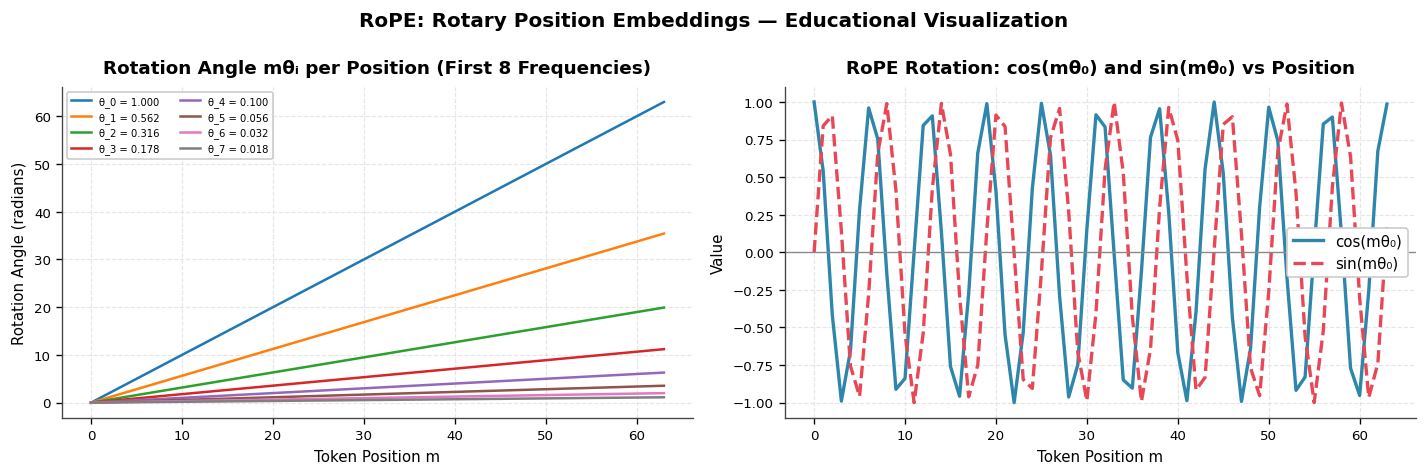


── Sample Predictions ──
Text                                                         True         Predicted      Conf
-----------------------------------------------------------------------------------------------
Fears for T N pension after talks Unions representing w      Business     Sci/Tech     0.9732 ✗
The Race is On: Second Private Team Sets Launch Date fo      Sci/Tech     Sci/Tech     0.9601 ✓
Ky. Company Wins Grant to Study Peptides (AP) AP - A co      Sci/Tech     Sci/Tech     0.9675 ✓
Prediction Unit Helps Forecast Wildfires (AP) AP - It's      Sci/Tech     World        0.4813 ✗
Calif. Aims to Limit Farm-Related Smog (AP) AP - Southe      Sci/Tech     World        0.3979 ✗
Open Letter Against British Copyright Indoctrination in      Sci/Tech     Sci/Tech     0.8427 ✓
Loosing the War on Terrorism \\"Sven Jaschan, self-conf      Sci/Tech     Sci/Tech     0.8840 ✓
FOAFKey: FOAF, PGP, Key Distribution, and Bloom Filters      Sci/Tech     World        0.8449 ✗
E-mail scam targ

In [13]:
# ============================================================
# SECTION 11 — ADDITIONAL EDUCATIONAL OUTPUTS
# ============================================================

# ── (a) Tokenized sentence example ───────────────────────────
# Use a hardcoded example string so this cell has no
# dependency on an 'examples' list from a previous cell.
sample_text = (
    "NASA launches new telescope to study distant galaxies "
    "and explore the origins of the universe."
)
sample_enc  = tokenizer(
    sample_text,
    max_length     = MAX_LENGTH,
    truncation     = True,
    padding        = "max_length",
)
sample_ids  = sample_enc["input_ids"]
sample_toks = tokenizer.convert_ids_to_tokens(sample_ids)

print("\n── Tokenization Example ──")
print(f"Original : {sample_text}")
print(f"Tokens   : {sample_toks[:15]} …")
print(f"IDs      : {sample_ids[:15]} …")
print(f"Decoded  : "
      f"{tokenizer.decode(sample_ids, skip_special_tokens=True)}")

# ── (b) RoPE rotation visualization ──────────────────────────
fig2, axes = plt.subplots(1, 2, figsize=(12, 4),
                          facecolor="white")
fig2.suptitle(
    "RoPE: Rotary Position Embeddings — Educational Visualization",
    fontsize=12, fontweight="bold", color="black")

# Left: rotation angle mθᵢ vs token position for 8 frequencies
ax_r1 = axes[0]
style_ax(ax_r1,
         "Rotation Angle mθᵢ per Position (First 8 Frequencies)",
         "Token Position m", "Rotation Angle (radians)")
for fi in range(min(8, len(inv_freqs))):
    ax_r1.plot(
        positions[:64],
        positions[:64] * inv_freqs[fi],
        lw=1.5,
        label=f"θ_{fi} = {inv_freqs[fi]:.3f}")
ax_r1.legend(fontsize=6, ncol=2)

# Right: cos and sin of the lowest-frequency rotation
ax_r2 = axes[1]
style_ax(ax_r2,
         "RoPE Rotation: cos(mθ₀) and sin(mθ₀) vs Position",
         "Token Position m", "Value")
ax_r2.plot(positions[:64],
           np.cos(positions[:64] * inv_freqs[0]),
           color=PALETTE[0], lw=2, label="cos(mθ₀)")
ax_r2.plot(positions[:64],
           np.sin(positions[:64] * inv_freqs[0]),
           color=PALETTE[1], lw=2,
           linestyle="--", label="sin(mθ₀)")
ax_r2.legend(fontsize=9)
ax_r2.axhline(0, color="#888888", lw=0.8)

plt.tight_layout()
buf2 = BytesIO()
fig2.savefig(buf2, format="png", dpi=120,
             bbox_inches="tight", facecolor="white")
buf2.seek(0)
display(IPImage(data=buf2.read()))
plt.close(fig2)

# ── (c) Sample predictions table ─────────────────────────────
# FIX: test_data (HuggingFace split) has no 'text' column.
# Use test_dataset.texts — the pre-extracted plain Python list
# built by concatenating 'title' + ' ' + 'description' in
# AGNewsDataset.__init__. This is always available and has
# exactly the same ordering as final_labels_np / final_preds_np.
print("\n── Sample Predictions ──")
print(f"{'Text':<60} {'True':<12} {'Predicted':<12} {'Conf':>6}")
print("-" * 95)

n_show = min(10, len(final_labels_np))
for i in range(n_show):
    # Pull pre-extracted text — no HuggingFace column access
    raw_text = test_dataset.texts[i][:55]
    true_cls = CLASS_NAMES[final_labels_np[i]]
    pred_cls = CLASS_NAMES[final_preds_np[i]]
    conf     = final_probs_np[i].max()
    marker   = "✓" if true_cls == pred_cls else "✗"
    print(f"{raw_text:<60} {true_cls:<12} {pred_cls:<12} "
          f"{conf:.4f} {marker}")

print("\n── RoFormer Educational Implementation Complete ──")
print(f"Best validation accuracy achieved : {best_val_acc:.4f}")
print("RoPE successfully applied to Q and K projections.")
print("Dashboard displayed inline via IPython.display.")

# Related Works Table: RoFormer / RoPE

---

| # | Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|---|
| 1 | Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, Ł., & Polosukhin, I. | 2017 | Attention Is All You Need | NeurIPS | Foundational work introducing the Transformer architecture and sinusoidal absolute position encoding; serves as the primary baseline architecture that RoFormer modifies by replacing sinusoidal embeddings with RoPE. |
| 2 | Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. | 2019 | BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding | NAACL-HLT | Introduces trainable absolute position embeddings added to input representations; used as the direct pre-training baseline against which RoFormer's convergence speed and GLUE performance are compared. |
| 3 | Radford, A., & Narasimhan, K. | 2018 | Improving Language Understanding by Generative Pre-Training | Unpublished (OpenAI) | Employs trainable absolute position embeddings in GPT; cited as a representative prior approach to absolute position encoding that RoPE supersedes. |
| 4 | Radford, A., Wu, J., Child, R., Luan, D., Amodei, D., & Sutskever, I. | 2019 | Language Models Are Unsupervised Multitask Learners | Unpublished (OpenAI) | Employs absolute position embeddings in GPT-2 for language modeling; cited as further evidence of the prevalence of additive absolute position encoding in PLMs. |
| 5 | Gehring, J., Auli, M., Grangier, D., Yarats, D., & Dauphin, Y. N. | 2017 | Convolutional Sequence to Sequence Learning | ICML | Introduces trainable absolute position embeddings in CNN-based sequence models; cited as an early precedent for learnable positional representations prior to the Transformer era. |
| 6 | Shaw, P., Uszkoreit, J., & Vaswani, A. | 2018 | Self-Attention with Relative Position Representations | NAACL-HLT | Proposes one of the earliest relative position encoding schemes by adding trainable relative position vectors to keys and values; cited as a foundational additive relative position method that RoPE contrasts against. |
| 7 | Dai, Z., Yang, Z., Yang, Y., Carbonell, J., Le, Q. V., & Salakhutdinov, R. | 2019 | Transformer-XL: Attentive Language Models Beyond a Fixed-Length Context | ACL | Introduces a relative position encoding via decomposition of the attention score into four terms and substitution of sinusoidal relative embeddings; one of the primary additive relative encoding baselines formally compared against RoPE's multiplicative formulation. |
| 8 | Yang, Z., Dai, Z., Yang, Y., Carbonell, J., Salakhutdinov, R., & Le, Q. V. | 2019 | XLNet: Generalized Autoregressive Pretraining for Language Understanding | NeurIPS | Builds on Transformer-XL's relative position encoding for autoregressive pre-training; cited as a further development of additive relative position encoding that still lacks the multiplicative geometric properties of RoPE. |
| 9 | Raffel, C., Shazeer, N., Roberts, A., Lee, K., Narang, S., Matena, M., Zhou, Y., Li, W., & Liu, P. J. | 2020 | Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer | JMLR | Proposes a simplified relative position encoding using a trainable scalar bias $b_{i,j}$ added to attention logits; cited as an additive relative encoding variant compared against RoPE in the systematic survey of prior methods. |
| 10 | He, P., Liu, X., Gao, J., & Chen, W. | 2020 | DeBERTa: Decoding-Enhanced BERT with Disentangled Attention | arXiv | Proposes disentangled relative position encoding using only the content-position cross terms from the Transformer-XL decomposition; cited as the most expressive additive relative encoding variant, which a comparative study finds most efficient among four variants. |
| 11 | Ke, G., He, D., & Liu, T. | 2020 | Rethinking Positional Encoding in Language Pre-Training | arXiv | Investigates the correlation between absolute positions and word content in the Transformer-XL decomposition; cited to motivate removing specific cross-terms and to contextualise RoPE's departure from additive decomposition entirely. |
| 12 | Huang, Z., Liang, D., Xu, P., & Xiang, B. | 2020 | Improve Transformer Models with Better Relative Position Embeddings | EMNLP Findings | Proposes improved relative position embeddings injected into attention weights; cited as another additive relative encoding variant within the survey of prior methods that RoPE unifies and improves upon. |
| 13 | Huang, C.-Z. A., Vaswani, A., Uszkoreit, J., Shazeer, N., Simon, I., Hawthorne, C., Dai, A. M., Hoffman, M., Dinculescu, M., & Eck, D. | 2018 | Music Transformer | arXiv | Applies relative position encoding to music generation with long sequences; cited as an early application domain motivating the need for relative position encoding that generalises to long-range dependencies. |
| 14 | Parikh, A. P., Täckström, O., Das, D., & Uszkoreit, J. | 2016 | A Decomposable Attention Model for Natural Language Inference | EMNLP | An early application of decomposed attention for NLI; cited as a precursor to the structured decomposition of position-augmented attention scores explored in subsequent relative encoding methods. |
| 15 | Lan, Z., Chen, M., Goodman, S., Gimpel, K., Sharma, P., & Soricut, R. | 2020 | ALBERT: A Lite BERT for Self-Supervised Learning of Language Representations | ICLR | Uses trainable absolute position embeddings within a parameter-efficient BERT variant; cited as a representative PLM employing absolute position encoding that RoPE proposes to replace. |
| 16 | Clark, K., Luong, M.-T., Le, Q. V., & Manning, C. D. | 2020 | ELECTRA: Pre-training Text Encoders as Discriminators Rather Than Generators | ICLR | Employs absolute position embeddings in a discriminative pre-training framework; cited alongside BERT and ALBERT as representative PLMs using additive absolute position encoding. |
| 17 | Liu, X., Yu, H.-F., Dhillon, I. S., & Hsieh, C.-J. | 2020 | Learning to Encode Position for Transformer with Continuous Dynamical Model | ICML | Models position encoding through a Neural ODE framework, encoding positional dependencies continuously; cited as an alternative non-additive position encoding approach that nonetheless adds position to representations rather than rotating them. |
| 18 | Wang, B., Zhao, D., Lioma, C., Li, Q., Zhang, P., & Simonsen, J. G. | 2020 | Encoding Word Order in Complex Embeddings | ICLR | Proposes encoding positional information in complex-valued embedding space; cited as a conceptually related approach using complex numbers, which RoPE generalises and grounds more rigorously through the rotation group formalism. |
| 19 | Yun, C., Bhojanapalli, S., Rawat, A. S., Reddi, S., & Kumar, S. | 2020 | Are Transformers Universal Approximators of Sequence-to-Sequence Functions? | ICLR | Demonstrates that self-attention is position-agnostic without explicit positional encoding; directly motivates the entire RoPE research programme by formalising the need to inject positional information into transformer attention. |
| 20 | Islam, M. A., Jia, S., & Bruce, N. D. B. | 2020 | How Much Position Information Do Convolutional Neural Networks Encode? | arXiv | Shows that CNNs can implicitly encode position via padding operations; cited in the introduction to contrast CNNs with Transformers and establish that PLMs require explicit positional injection. |
| 21 | Katharopoulos, A., Vyas, A., Pappas, N., & Fleuret, F. | 2020 | Transformers Are RNNs: Fast Autoregressive Transformers with Linear Attention | ICML | Introduces linear attention by replacing the softmax kernel with non-negative feature maps to achieve $O(N)$ complexity; provides the linear attention framework into which RoPE is integrated and evaluated as a relative position encoding compatible with sub-quadratic attention. |
| 22 | Shen, Z., Zhang, M., Zhao, H., Yi, S., & Li, H. | 2021 | Efficient Attention: Attention with Linear Complexities | WACV | Proposes an efficient attention mechanism using separate softmax normalisation of queries and keys; cited as a second linear attention variant whose feature-map structure is compatible with RoPE's norm-preserving rotation. |
| 23 | Choromanski, K., Likhosherstov, V., Dohan, D., Song, X., Gane, A., Sarlós, T., Hawkins, P., Davis, J., Mohiuddin, A., Kaiser, L., Belanger, D., Colwell, L. J., & Weller, A. | 2020 | Rethinking Attention with Performers | arXiv | Introduces the Performer model with FAVOR+ linear attention; used as the direct experimental testbed to demonstrate that incorporating RoPE into linear attention leads to improved convergence on the Enwik8 benchmark. |
| 24 | Wei, V. J., Ren, X., Li, X., Huang, W., Liao, Y., Wang, Y., Lin, J., Jiang, X., Chen, X., & Liu, Q. | 2019 | NEZHA: Neural Contextualized Representation for Chinese Language Understanding | arXiv | Proposes a Chinese PLM using functional relative position encoding; included in the cross-comparison table of Chinese pre-trained models against which RoFormer is benchmarked on the CAIL2019-SCM long-text task. |
| 25 | Su, J. | 2020 | WoBERT: Word-Based Chinese BERT Model | GitHub Technical Report | Introduces a word-tokenised Chinese BERT with absolute position embeddings; serves as the direct baseline replaced by RoPE in the Chinese RoFormer experiments, and the primary comparison model on CAIL2019-SCM. |